In [2]:
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import subplot
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv(r"C:\Users\LOQ\Desktop\IT\AI course\Data\delaney_solubility_with_descriptors.csv")
print(df.head())

   MolLogP    MolWt  NumRotatableBonds  AromaticProportion  logS
0   2.5954  167.850                0.0                 0.0 -2.18
1   2.3765  133.405                0.0                 0.0 -2.00
2   2.5938  167.850                1.0                 0.0 -1.74
3   2.0289  133.405                1.0                 0.0 -1.48
4   2.9189  187.375                1.0                 0.0 -3.04


In [4]:
print(df[["MolLogP","MolWt", "NumRotatableBonds","AromaticProportion","logS"]].corr()["logS"])

MolLogP              -0.827959
MolWt                -0.637324
NumRotatableBonds    -0.238508
AromaticProportion   -0.268108
logS                  1.000000
Name: logS, dtype: float64


In [5]:
df.describe()

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
count,1144.000000,1144.000000,1144.000000,1144.000000,1144.000000
mean,2.449133,204.631675,2.173951,0.364932,-3.057997
std,1.866003,102.620500,2.627398,0.343305,2.096502
min,-7.571400,16.043000,0.000000,0.000000,-11.600000
25%,1.414900,122.126000,0.000000,0.000000,-4.332250
50%,2.340300,183.594500,1.000000,0.375000,-2.870500
75%,3.406475,270.715750,3.000000,0.666667,-1.600000
max,10.388600,780.949000,23.000000,1.000000,1.580000


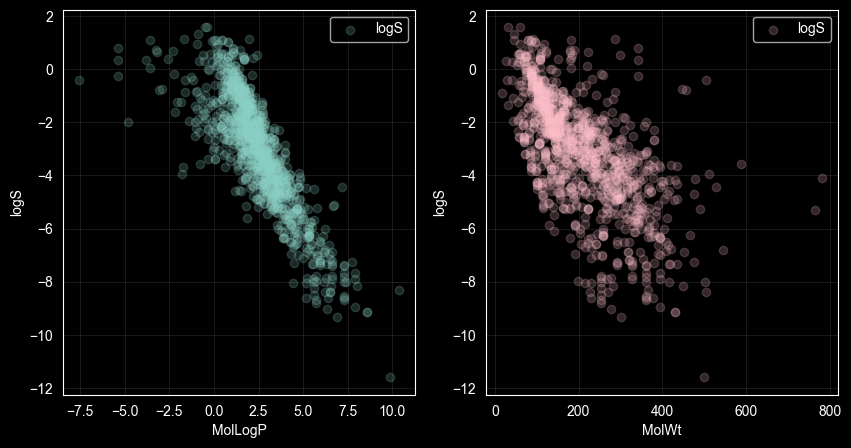

In [7]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(df["MolLogP"],df["logS"],alpha=0.2,label="logS")
plt.xlabel("MolLogP")
plt.ylabel("logS")
plt.grid(True,alpha=0.1)
plt.legend()


plt.subplot(1,2,2)
plt.scatter(df["MolWt"],df["logS"],alpha=0.2,label="logS",color="pink")
plt.xlabel("MolWt")
plt.ylabel("logS")
plt.legend()
plt.grid(True,alpha=0.1)
plt.show()


In [21]:
x_train , x_test, y_train, y_test = train_test_split(df[["MolLogP"]], df["logS"], test_size = 0.2, random_state = 42)

print("x_train",x_train)
print("x_train.shape :",x_train.shape)
print("----------")
print("y_train",y_train)
print("y_train.shape :",y_train.shape)
print("----------")
print("x_test",x_test)
print("x_test.shape :",x_test.shape)
print("----------")
print("y_test",y_test)
print("y_test.shape :",y_test.shape)
print("----------")


x_train       MolLogP
643   3.61260
722   6.48760
570   3.15380
66    0.77880
1002  1.82140
...       ...
1044  2.82960
1095  2.10750
1130  4.14820
860   4.25720
1126  6.25676

[915 rows x 1 columns]
x_train.shape : (915, 1)
----------
y_train 643    -4.300
722    -8.400
570    -3.754
66      0.000
1002   -1.340
        ...  
1044   -3.324
1095   -1.620
1130   -5.680
860    -4.770
1126   -6.010
Name: logS, Length: 915, dtype: float64
y_train.shape : (915,)
----------
x_test       MolLogP
218   1.55740
809   5.20590
501   4.18090
649   2.05760
323   0.72822
...       ...
361  -0.50840
292   1.94750
1119  2.16090
557   3.36680
448   1.40120

[229 rows x 1 columns]
x_test.shape : (229, 1)
----------
y_test 218    -0.890
809    -6.890
501    -4.530
649    -3.420
323    -0.466
        ...  
361     1.580
292    -0.980
1119   -0.220
557    -5.190
448    -1.090
Name: logS, Length: 229, dtype: float64
y_test.shape : (229,)
----------


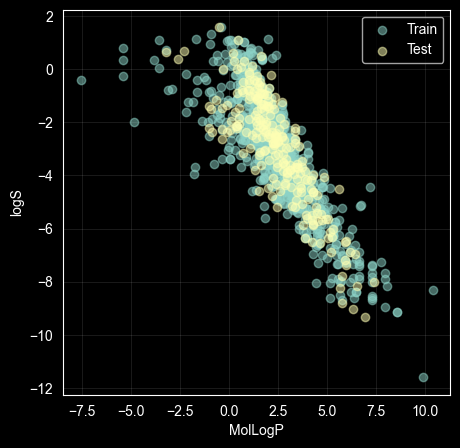

In [17]:

plt.figure(figsize=(5,5))
plt.scatter(x_train,y_train,alpha=0.5,label="Train")
plt.scatter(x_test,y_test,alpha=0.5,label="Test")
plt.xlabel("MolLogP")
plt.ylabel("logS")
plt.grid(True,alpha=0.1)
plt.legend()


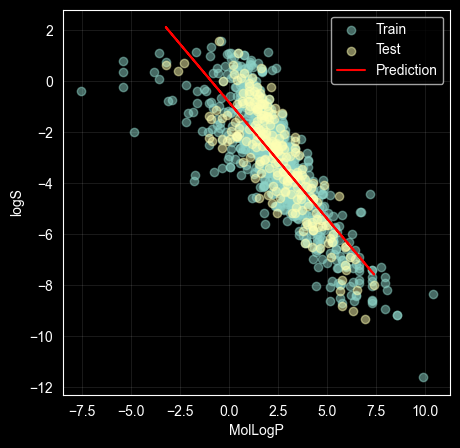

In [31]:
model = LinearRegression()
model.fit(x_train,y_train)

testing_prediction = model.predict(x_test)
training_prediction = model.predict(x_train)


plt.figure(figsize=(5,5))
plt.scatter(x_train,y_train,alpha=0.5,label="Train")
plt.scatter(x_test,y_test,alpha=0.5,label="Test")
plt.plot(x_test,testing_prediction,color="red",label="Prediction")
plt.xlabel("MolLogP")
plt.ylabel("logS")
plt.grid(True,alpha=0.1)
plt.legend()